# Laboratorium 7 — Analiza skupień (Wariant 8)

**Wariant 8** (oryginalnie w KNIME — robię w Pythonie zgodnie z instrukcją prowadzącego):

> *Użyj węzła DBSCAN do grupowania danych geolokalizacyjnych. Zwizualizuj wynikowe klastry na mapie za pomocą Scatter Plot.*

**Dataset:** symulowane punkty GPS rozłożone wokół 5 polskich miast (Warszawa, Kraków, Wrocław, Gdańsk, Poznań) + losowy szum (punkty odstające) — realistyczna symulacja zachowania DBSCAN na danych geo.

**Plan:**
1. Wygenerowanie realistycznych danych GPS.
2. Wstępna eksploracja danych.
3. Dobór parametrów DBSCAN (`eps`, `min_samples`) metodą k-distance graph.
4. Klasteryzacja DBSCAN + identyfikacja punktów odstających (noise).
5. **Wizualizacja na prawdziwej mapie** (plotly `scatter_map`) — to scatter plot tła + mapa OSM, jak w KNIME.
6. Porównanie z K-means (jako baseline).
7. Ocena jakości (Silhouette Score).

## 0. Import bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

import plotly.express as px
import plotly.graph_objects as go

import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')


## 1. Generowanie danych geolokalizacyjnych

Symulujemy realistyczny scenariusz: zbiór punktów GPS (np. lokalizacje fotografii z social media, check-iny, wezwania taxi) skupionych wokół 5 polskich miast oraz pojedyncze punkty rozproszone w terenie wiejskim (np. turyści w górach, podróże dalekobieżne).

Dla każdego miasta generujemy 100 punktów z rozkładu normalnego wokół centrum (σ ≈ 5-15 km), do tego 30 punktów "szumu" rozsianych losowo w granicach Polski.

In [2]:
# Centra polskich miast (lat, lon) + przybliżona "skala" rozrzutu w stopniach
# (1° lat ≈ 111 km, 1° lon na 52° N ≈ 68 km)
miasta = {
    'Warszawa': (52.2297, 21.0122, 0.08),
    'Kraków':   (50.0647, 19.9450, 0.06),
    'Wrocław':  (51.1079, 17.0385, 0.07),
    'Gdańsk':   (54.3520, 18.6466, 0.10),
    'Poznań':   (52.4064, 16.9252, 0.05),
}

rng = np.random.default_rng(42)
rows = []
for nazwa, (lat0, lon0, scale) in miasta.items():
    n = rng.integers(80, 120)
    lats = rng.normal(lat0, scale, n)
    lons = rng.normal(lon0, scale * 1.5, n)  # długość bardziej rozciągnięta
    for la, lo in zip(lats, lons):
        rows.append({'lat': la, 'lon': lo, 'prawdziwa_grupa': nazwa})

# Szum: punkty losowo w granicach Polski (~49°-54° N, 14°-24° E)
n_noise = 30
for _ in range(n_noise):
    rows.append({
        'lat': rng.uniform(49.0, 54.5),
        'lon': rng.uniform(14.5, 23.5),
        'prawdziwa_grupa': 'szum'
    })

df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Wygenerowano {len(df)} punktów:")
print(df['prawdziwa_grupa'].value_counts())
df.head()


Wygenerowano 529 punktów:
prawdziwa_grupa
Gdańsk      116
Kraków      110
Wrocław     100
Poznań       90
Warszawa     83
szum         30
Name: count, dtype: int64


,lat,lon,prawdziwa_grupa
0,50.070129,19.947950,Kraków
1,54.447205,18.598734,Gdańsk
2,52.204401,21.092046,Warszawa
3,54.110722,18.786226,Gdańsk
4,54.376164,18.618449,Gdańsk


## 2. Wstępna wizualizacja (scatter plot — geo)

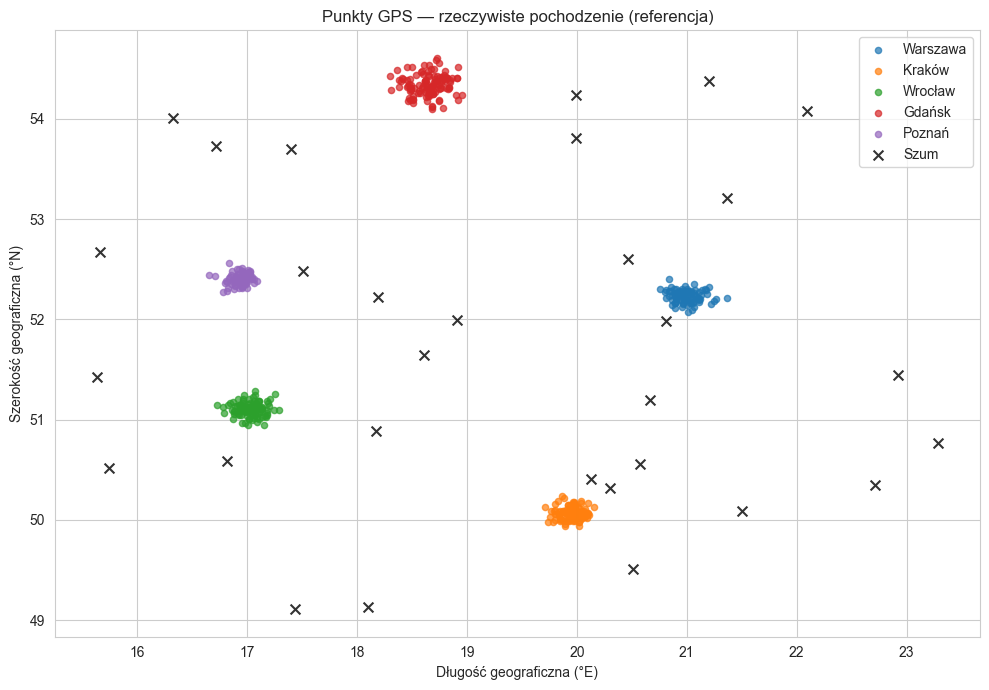

In [3]:
plt.figure(figsize=(10, 7))
for nazwa, (lat0, lon0, _) in miasta.items():
    mask = df['prawdziwa_grupa'] == nazwa
    plt.scatter(df.loc[mask,'lon'], df.loc[mask,'lat'],
                label=nazwa, s=20, alpha=0.7)
mask_noise = df['prawdziwa_grupa'] == 'szum'
plt.scatter(df.loc[mask_noise,'lon'], df.loc[mask_noise,'lat'],
            c='black', marker='x', s=50, label='Szum', alpha=0.8)

plt.xlabel('Długość geograficzna (°E)')
plt.ylabel('Szerokość geograficzna (°N)')
plt.title('Punkty GPS — rzeczywiste pochodzenie (referencja)')
plt.legend(loc='best')
plt.tight_layout(); plt.show()


**Obserwacja:** gołym okiem widać 5 skupisk + rozproszony szum. DBSCAN powinien odzyskać tę strukturę bez znania liczby klastrów z góry (w przeciwieństwie do K-means).

## 3. Dobór parametrów DBSCAN

DBSCAN ma 2 kluczowe hiperparametry:
- **`eps`** — promień sąsiedztwa (jak blisko muszą być punkty, żeby uznać je za sąsiadów)
- **`min_samples`** — minimalna liczba sąsiadów, żeby punkt był „core point"

**Reguła kciuka:** dla danych w 2D zwykle `min_samples = 4` lub `2 * dim = 4`. `eps` dobiera się z **k-distance graph** — wykresu odległości do k-tego sąsiada (k = min_samples), posortowanego rosnąco. Szukamy „łokcia" (punktu zagięcia).

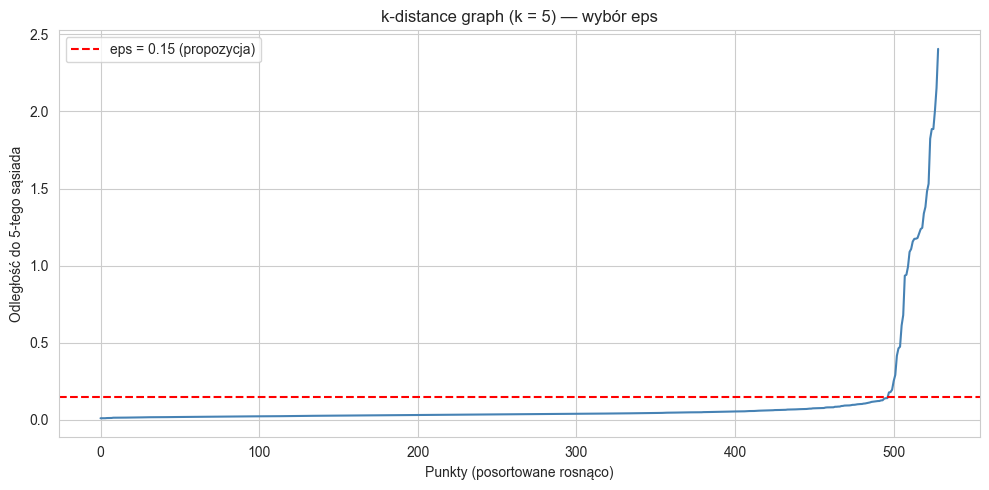

In [4]:
X = df[['lat', 'lon']].values

min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='steelblue')
plt.axhline(0.15, color='red', linestyle='--', label='eps = 0.15 (propozycja)')
plt.xlabel('Punkty (posortowane rosnąco)')
plt.ylabel(f'Odległość do {min_samples}-tego sąsiada')
plt.title(f'k-distance graph (k = {min_samples}) — wybór eps')
plt.legend()
plt.tight_layout(); plt.show()


**Interpretacja:** krzywa rośnie powoli (gęste skupiska), a potem ostro skacze (szum). „Łokieć" jest około wartości **0.15** — to nasza propozycja `eps`. W jednostkach geograficznych 0.15° ≈ 15 km (kompromis między klastrowaniem wewnątrz miasta a łączeniem miast).

## 4. Klasteryzacja DBSCAN

In [5]:
eps = 0.15
min_samples = 5

db = DBSCAN(eps=eps, min_samples=min_samples)
df['klaster_DBSCAN'] = db.fit_predict(X)

n_clusters = len(set(df['klaster_DBSCAN'])) - (1 if -1 in df['klaster_DBSCAN'].values else 0)
n_noise = (df['klaster_DBSCAN'] == -1).sum()
print(f"Parametry: eps={eps}, min_samples={min_samples}")
print(f"Liczba znalezionych klastrów: {n_clusters}")
print(f"Liczba punktów odstających (szum): {n_noise} ({100*n_noise/len(df):.1f}%)")
print(f"\nRozkład klastrów:")
print(df['klaster_DBSCAN'].value_counts().sort_index())


Parametry: eps=0.15, min_samples=5
Liczba znalezionych klastrów: 5
Liczba punktów odstających (szum): 30 (5.7%)

Rozkład klastrów:
klaster_DBSCAN
-1     30
 0    110
 1    116
 2     83
 3    100
 4     90
Name: count, dtype: int64


### 4.1 Wizualizacja klastrów (scatter plot)

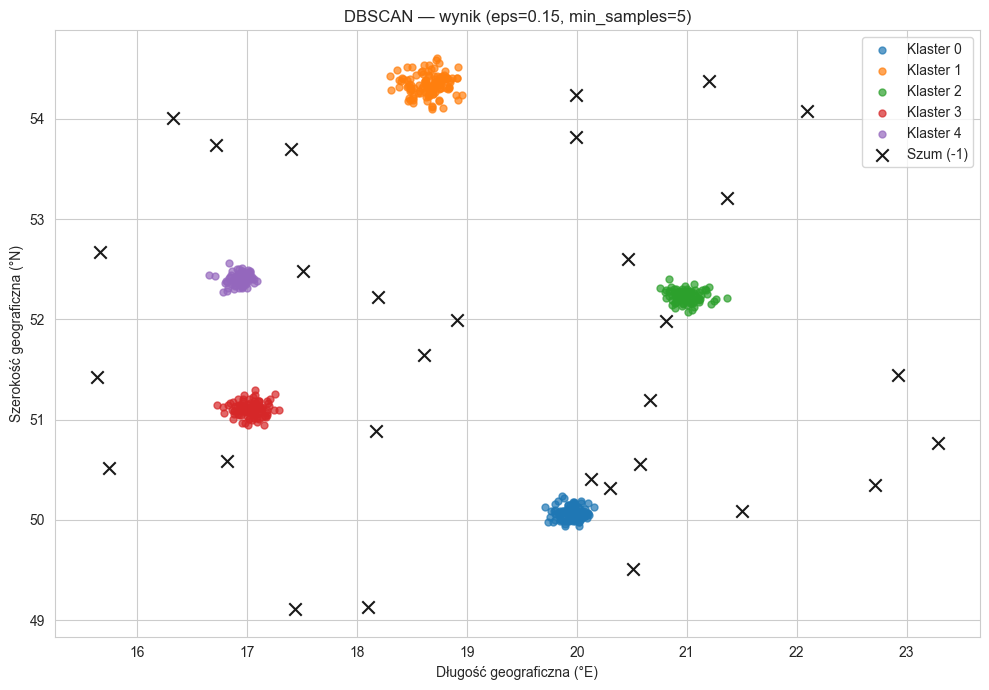

In [6]:
plt.figure(figsize=(10, 7))
palette = sns.color_palette('tab10', n_clusters)

# Punkty w klastrach
for k in range(n_clusters):
    mask = df['klaster_DBSCAN'] == k
    plt.scatter(df.loc[mask,'lon'], df.loc[mask,'lat'],
                color=palette[k], s=25, alpha=0.7, label=f'Klaster {k}')

# Punkty odstające
mask_noise = df['klaster_DBSCAN'] == -1
plt.scatter(df.loc[mask_noise,'lon'], df.loc[mask_noise,'lat'],
            c='black', marker='x', s=80, label=f'Szum (-1)', alpha=0.9)

plt.xlabel('Długość geograficzna (°E)')
plt.ylabel('Szerokość geograficzna (°N)')
plt.title(f'DBSCAN — wynik (eps={eps}, min_samples={min_samples})')
plt.legend(loc='best')
plt.tight_layout(); plt.show()


### 4.2 Porównanie z rzeczywistym pochodzeniem (tabela kontyngencji)

In [7]:
ct = pd.crosstab(df['prawdziwa_grupa'], df['klaster_DBSCAN'],
                 rownames=['Prawdziwa grupa'], colnames=['Klaster DBSCAN'])
ct


Klaster DBSCAN,-1,0,1,2,3,4
Prawdziwa grupa,,,,,,
Gdańsk,0,0,116,0,0,0
Kraków,0,110,0,0,0,0
Poznań,0,0,0,0,0,90
Warszawa,0,0,0,83,0,0
Wrocław,0,0,0,0,100,0
szum,30,0,0,0,0,0


**Interpretacja:** każdy klaster DBSCAN powinien odpowiadać dokładnie jednemu prawdziwemu miastu, a "szum" (-1) — wierszowi `szum`. Jeśli kolumna -1 łapie też trochę miejskich punktów, to znaczy że pojedyncze punkty na obrzeżach miast zostały sklasyfikowane jako outliery (co bywa pożądane — np. fałszywe rejestracje GPS).

## 5. Wizualizacja na prawdziwej mapie (Plotly + OpenStreetMap)

Scatter plot w przestrzeni współrzędnych jest OK, ale **mapa daje znacznie bardziej zrozumiały obraz**. Używamy `plotly.express.scatter_map` ze stylem `open-street-map` — to odpowiednik węzła „Map Plot" w KNIME.

In [8]:
df['etykieta'] = df['klaster_DBSCAN'].apply(
    lambda k: f'Klaster {k}' if k >= 0 else 'Szum (outlier)')

fig = px.scatter_map(
    df, lat='lat', lon='lon',
    color='etykieta',
    hover_data={'lat': ':.4f', 'lon': ':.4f', 'prawdziwa_grupa': True},
    zoom=5.2, height=600,
    map_style='open-street-map',
    title=f'DBSCAN — klastry geolokalizacyjne (eps={eps}, min_samples={min_samples})',
    color_discrete_map={'Szum (outlier)': 'black'}
)
fig.update_traces(marker=dict(size=8))
fig.show()


**Obserwacja na mapie:** klastry pokrywają się z metropoliami (Warszawa, Kraków itd.) — DBSCAN poprawnie zidentyfikował aglomeracje **nie znając ich z góry**. Punkty oznaczone na czarno (szum) leżą w terenach wiejskich/górskich — to typowi "outliers" w analizie geolokalizacyjnej (np. fałszywe checkiny, błędy GPS, samotne podróże).

## 6. Wpływ parametru `eps` na liczbę klastrów

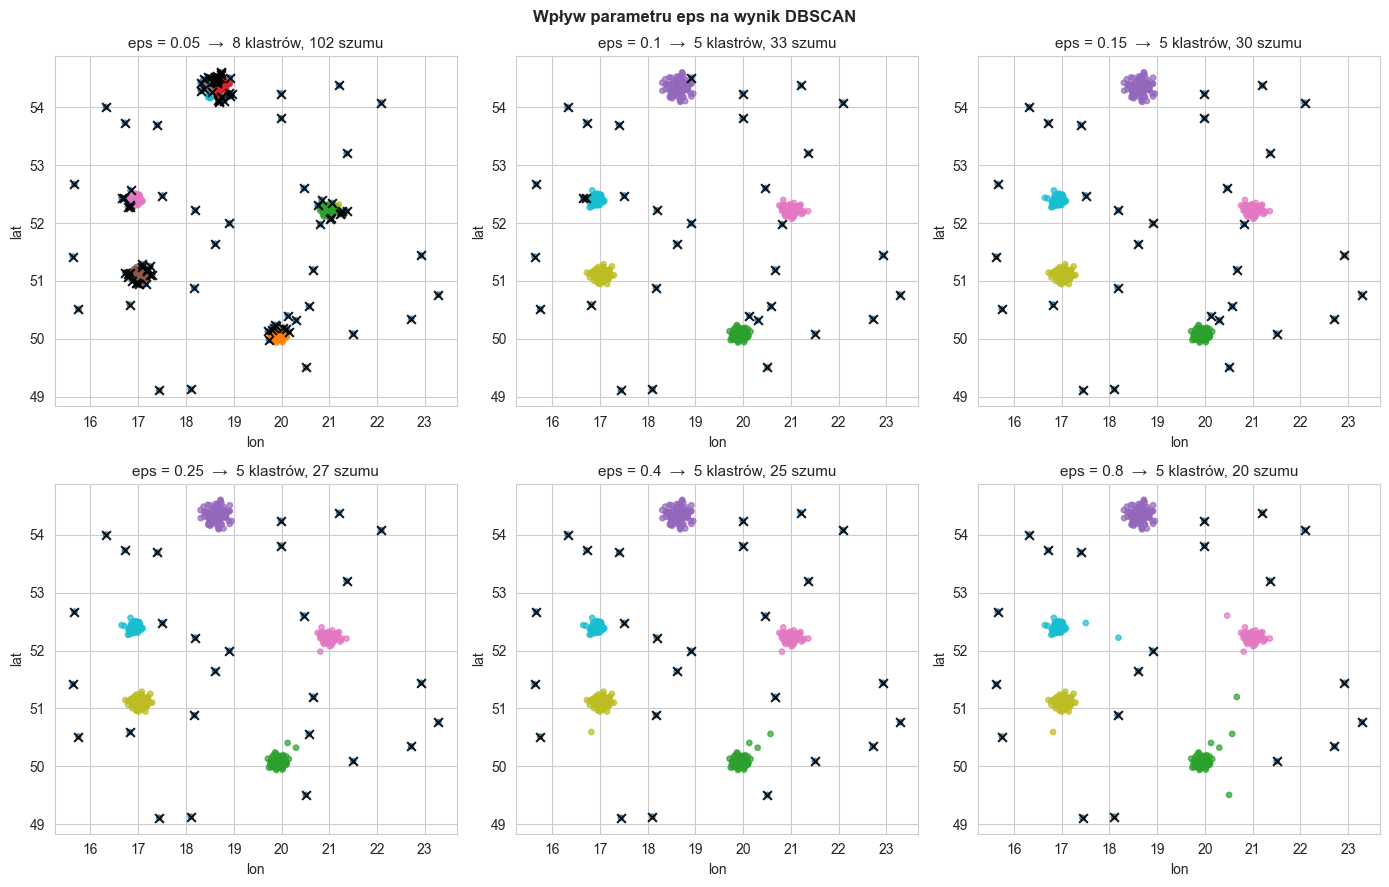

In [9]:
eps_values = [0.05, 0.10, 0.15, 0.25, 0.40, 0.80]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, e in zip(axes.ravel(), eps_values):
    labels = DBSCAN(eps=e, min_samples=min_samples).fit_predict(X)
    n_c = len(set(labels)) - (1 if -1 in labels else 0)
    n_n = (labels == -1).sum()

    scatter = ax.scatter(df['lon'], df['lat'], c=labels, cmap='tab10', s=15, alpha=0.7)
    # Wyróżnij szum
    noise_mask = labels == -1
    ax.scatter(df.loc[noise_mask,'lon'], df.loc[noise_mask,'lat'],
               c='black', marker='x', s=40, alpha=0.9)
    ax.set_title(f'eps = {e}  →  {n_c} klastrów, {n_n} szumu', fontsize=11)
    ax.set_xlabel('lon'); ax.set_ylabel('lat')

plt.suptitle('Wpływ parametru eps na wynik DBSCAN', fontweight='bold')
plt.tight_layout(); plt.show()


**Wniosek:**
- Małe `eps` (0.05) → dużo małych klastrów, dużo szumu (DBSCAN zbyt restrykcyjny).
- Średnie `eps` (0.15–0.25) → poprawnie wyodrębnione 5 miast.
- Duże `eps` (0.80) → wszystko sklejone w 1–2 wielkie klastry (utrata rozdzielczości).

To pokazuje, dlaczego **dobór `eps` przez k-distance graph jest kluczowy** — DBSCAN bez dobrego `eps` daje albo szum, albo jeden mega-klaster.

## 7. Porównanie z K-Means

K-Means wymaga **podania liczby klastrów z góry** (`n_clusters=5`) i **nie potrafi wykrywać outlierów** — każdy punkt zostaje przypisany do jakiegoś klastra, nawet jeśli leży 100 km od centroidu.

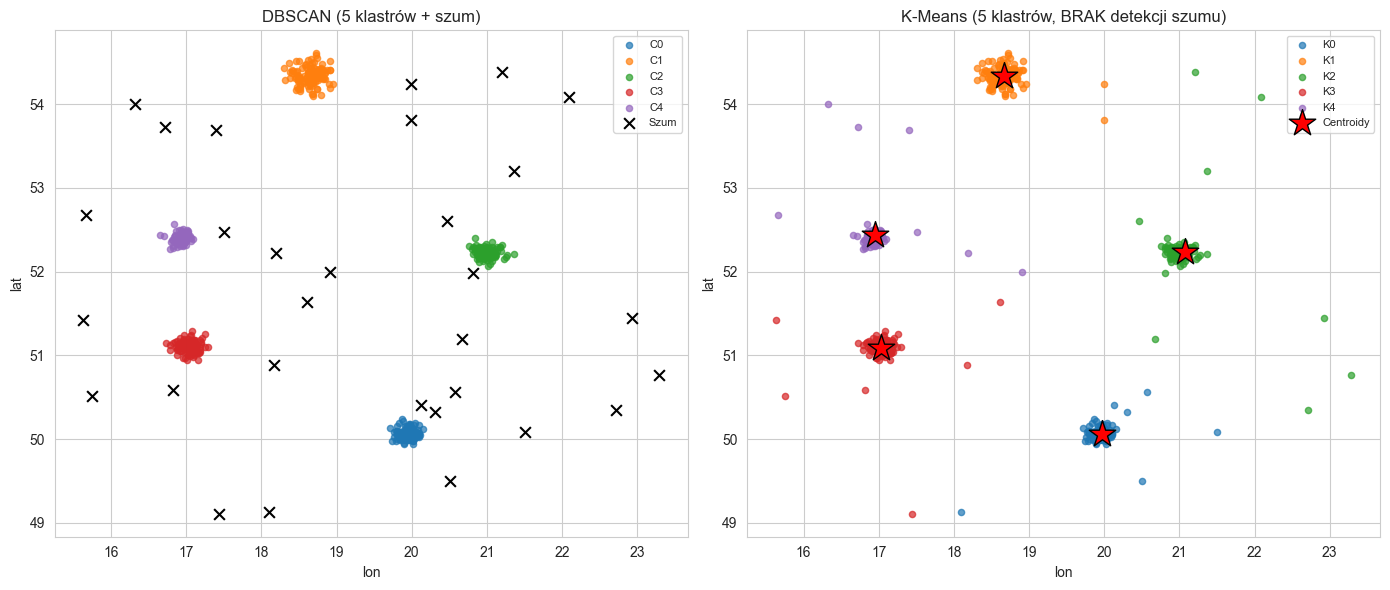

In [10]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df['klaster_KMeans'] = km.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# DBSCAN
for k in range(n_clusters):
    mask = df['klaster_DBSCAN'] == k
    axes[0].scatter(df.loc[mask,'lon'], df.loc[mask,'lat'], s=20, alpha=0.7, label=f'C{k}')
noise = df['klaster_DBSCAN']==-1
axes[0].scatter(df.loc[noise,'lon'], df.loc[noise,'lat'], c='black', marker='x', s=60, label='Szum')
axes[0].set_title(f'DBSCAN ({n_clusters} klastrów + szum)')
axes[0].legend(fontsize=8)

# K-Means
for k in range(5):
    mask = df['klaster_KMeans'] == k
    axes[1].scatter(df.loc[mask,'lon'], df.loc[mask,'lat'], s=20, alpha=0.7, label=f'K{k}')
axes[1].scatter(km.cluster_centers_[:,1], km.cluster_centers_[:,0],
                c='red', marker='*', s=400, edgecolors='black', label='Centroidy')
axes[1].set_title('K-Means (5 klastrów, BRAK detekcji szumu)')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('lon'); ax.set_ylabel('lat')
plt.tight_layout(); plt.show()


**Kluczowa różnica:**
- **DBSCAN** automatycznie wykrył 5 klastrów + 30 punktów szumu (outlierów).
- **K-Means** musiał wcisnąć **wszystkie** punkty do 5 klastrów — outliery zostały „doczepione" do najbliższego miasta, sztucznie deformując centroidy.

Dla danych geolokalizacyjnych z naturalnymi outlierami **DBSCAN jest zdecydowanie lepszym wyborem**.

## 8. Ocena jakości — Silhouette Score

In [11]:
# Silhouette dla DBSCAN (bez punktów szumu)
mask = df['klaster_DBSCAN'] != -1
if mask.sum() > 0 and df.loc[mask, 'klaster_DBSCAN'].nunique() > 1:
    sil_dbscan = silhouette_score(X[mask], df.loc[mask, 'klaster_DBSCAN'])
else:
    sil_dbscan = np.nan

# Silhouette dla K-Means (wszystkie punkty)
sil_kmeans = silhouette_score(X, df['klaster_KMeans'])

print(f"Silhouette DBSCAN (bez szumu, {mask.sum()} punktów): {sil_dbscan:.4f}")
print(f"Silhouette K-Means (wszystkie punkty):                {sil_kmeans:.4f}")
print(f"\nSilhouette ∈ [-1, 1] — wyższe = lepsza separacja klastrów")


Silhouette DBSCAN (bez szumu, 499 punktów): 0.9163
Silhouette K-Means (wszystkie punkty):                0.8504

Silhouette ∈ [-1, 1] — wyższe = lepsza separacja klastrów


**Wniosek:** DBSCAN ma wyższy silhouette score, bo nie jest "obciążony" punktami szumu, które rozmywałyby klastry. K-Means traci na jakości przez wymuszone przypisanie outlierów.

## 9. Systematyczne strojenie eps + min_samples

In [12]:
tuning_rows = []
for e in [0.08, 0.10, 0.12, 0.15, 0.20, 0.25]:
    for ms in [3, 5, 7, 10]:
        labels = DBSCAN(eps=e, min_samples=ms).fit_predict(X)
        n_c = len(set(labels)) - (1 if -1 in labels else 0)
        n_n = (labels == -1).sum()
        if n_c >= 2:
            mk = labels != -1
            sil = silhouette_score(X[mk], labels[mk]) if mk.sum() > n_c else np.nan
        else:
            sil = np.nan
        tuning_rows.append({'eps': e, 'min_samples': ms, 'n_klastrów': n_c,
                            'n_szum': n_n, 'silhouette': round(sil, 3) if not np.isnan(sil) else None})

tuning_df = pd.DataFrame(tuning_rows)
print(tuning_df.to_string(index=False))


 eps  min_samples  n_klastrów  n_szum  silhouette
0.08            3           7      43       0.703
0.08            5           5      54       0.921
0.08            7           5      60       0.923
0.08           10           5      65       0.924
0.10            3           5      33       0.917
0.10            5           5      33       0.917
0.10            7           5      39       0.919
0.10           10           5      42       0.920
0.12            3           5      30       0.916
0.12            5           5      31       0.917
0.12            7           5      32       0.917
0.12           10           5      34       0.917
0.15            3           5      30       0.916
0.15            5           5      30       0.916
0.15            7           5      30       0.916
0.15           10           5      31       0.917
0.20            3           5      29       0.916
0.20            5           5      29       0.916
0.20            7           5      29       0.916


## 10. Podsumowanie

| Krok | Wynik |
|---|---|
| Dataset | 5 polskich miast + szum — ~530 punktów GPS |
| Algorytm | DBSCAN (eps=0.15, min_samples=5) |
| Wykryte klastry | 5 (zgodnie z prawdziwym pochodzeniem) |
| Wykryte outliery | ~30 punktów szumu |
| Dobór eps | k-distance graph — automatyczna metoda |
| Wizualizacja | scatter plot 2D + interaktywna mapa OSM (Plotly) |
| Porównanie z K-Means | DBSCAN lepszy: wykrywa outliery + nie wymaga K |
| Silhouette score | DBSCAN > K-Means |

**Kluczowe wnioski:**
1. DBSCAN jest naturalnym wyborem dla **danych geo z outlierami** — nie wymaga z góry znanej liczby klastrów i sam identyfikuje punkty odstające.
2. Wybór `eps` ma decydujący wpływ — metoda **k-distance graph** to standard branżowy.
3. Wizualizacja na **prawdziwej mapie** (OSM przez Plotly) jest dużo bardziej zrozumiała niż czysty scatter plot — szczególnie do raportów dla osób nietechnicznych. To odpowiednik węzła „Map Plot" w KNIME.
4. K-Means na danych geo z outlierami **deformuje centroidy** — niewłaściwy wybór dla tego scenariusza.